<a href="https://colab.research.google.com/github/HarshaPriya03/PythonLearning/blob/main/Principal_Component_Analysis_Manpreet_Singh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Principal Component Analysis (PCA) — Complete Guide

**From Theory to Implementation — For Freshers to Experienced**

---

### What This Notebook Covers

| # | Section | What You'll Learn |
|---|---------|-------------------|
| 1 | Imports | Libraries we need |
| 2 | Intuition | What PCA does and why we need it |
| 3 | The Covariance Matrix | The core math object behind PCA |
| 4 | Derivation | Step-by-step: from objective → eigenvalue equation |
| 5 | Solving the Eigenvalue Problem | How to get the components |
| 6 | PCA From Scratch | Build it yourself in Python |
| 7 | Projection Visualization | See 2D→1D reduction |
| 8 | Explained Variance Ratio | How to choose number of components |
| 9 | Real Dataset — Iris | 4D → 2D |
| 10 | Real Dataset — Breast Cancer | 30D → 2D |
| 11 | Real Dataset — Digits (MNIST-like) | 64D → reduced |
| 12 | sklearn Pipeline | Production-ready PCA |
| 13 | PCA vs No PCA | Speed, accuracy, overfitting comparison |
| 14 | When PCA Fails | Assumptions and limitations |
| 15 | PCA vs LDA | Side-by-side comparison |
| 16 | Summary | Key takeaways |

## 1. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import time
import warnings
warnings.filterwarnings('ignore')

# sklearn
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import load_iris, load_wine, load_breast_cancer, load_digits, make_classification

# Plot settings
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## 2. Intuition — What is PCA and Why Do We Need It?

### The Problem

Real-world data has many features (columns). For example:
- A medical dataset might have 30 measurements per patient
- An image of 8×8 pixels has 64 features (one per pixel)
- A text dataset might have 10,000+ word counts

Problems with too many features:
1. **Slow training** — more features = more computation
2. **Overfitting** — model memorizes noise instead of patterns
3. **Can't visualize** — we can only see 2D or 3D plots
4. **Redundant features** — many features carry the same information (correlated)

### The Idea

PCA reduces the number of features while **keeping as much information as possible**.

"Information" in PCA = **variance** (how spread out the data is). If data is spread out in some direction, that direction carries information. If all points have the same value in some direction, that direction is useless.

PCA finds new directions (called **principal components**) where the data is most spread out, and throws away directions where the data is flat.

### Key Difference from LDA

| | PCA | LDA |
|---|---|---|
| Goal | Maximize **variance** (spread) | Maximize **class separation** |
| Uses labels? | **No** (unsupervised) | **Yes** (supervised) |
| Input matrix | Covariance matrix $C$ | $S_W^{-1} S_B$ |
| Best for | General dimensionality reduction, visualization | Classification tasks |

---

Let's see PCA in action with a simple 2D example:

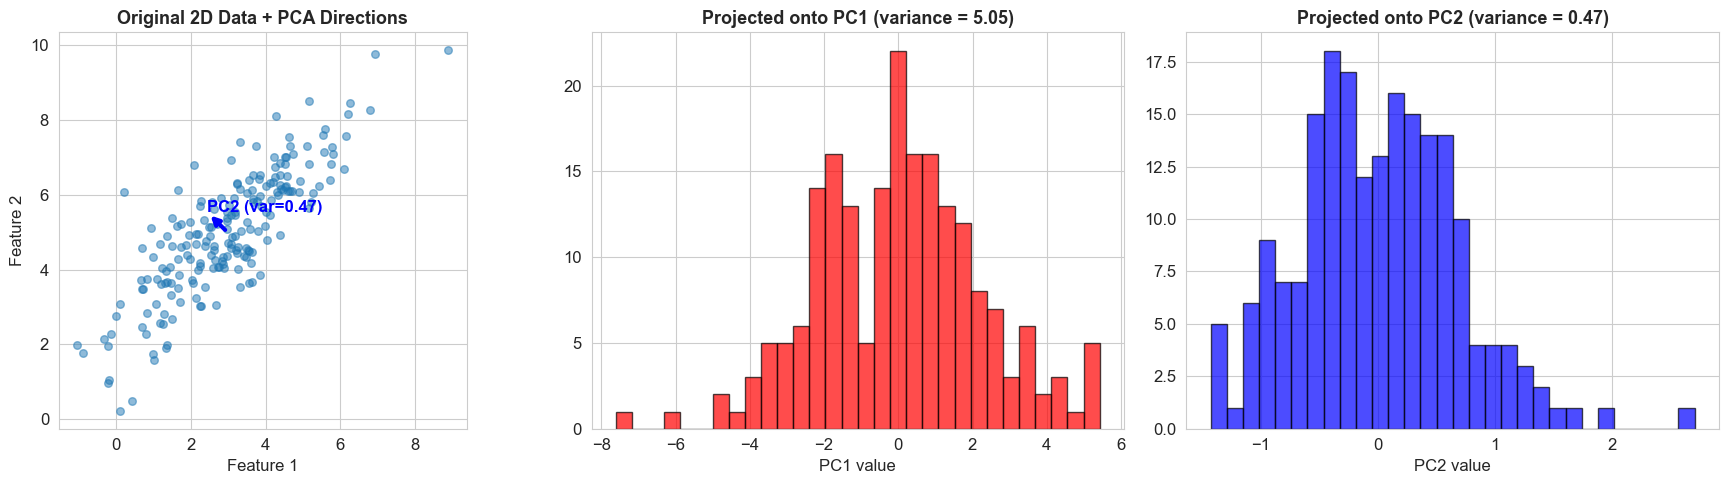

PC1 captures 91.6% of the total variance
PC2 captures 8.4% of the total variance

→ PC1 alone keeps most of the information. We could drop PC2 and lose very little.


In [ ]:
# ================================================================
# INTUITION: 2D data with correlated features
# ================================================================

np.random.seed(42)

# Create 2D data where features are correlated
# (points roughly along a diagonal line)
mean = [3, 5]
cov = [[3, 2.5], [2.5, 3]]  # features are correlated
X_demo = np.random.multivariate_normal(mean, cov, 200)

# Compute PCA directions
X_centered = X_demo - X_demo.mean(axis=0)
cov_matrix = np.cov(X_centered.T)
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
idx = np.argsort(eig_vals)[::-1]
eig_vals = eig_vals[idx]
eig_vecs = eig_vecs[:, idx]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original data with PCA directions
axes[0].scatter(X_demo[:, 0], X_demo[:, 1], alpha=0.5, s=30)
center = X_demo.mean(axis=0)
for i, (val, vec) in enumerate(zip(eig_vals, eig_vecs.T)):
    axes[0].annotate('', xy=center + vec * val * 1.5, xytext=center,
                    arrowprops=dict(arrowstyle='->', color=['red', 'blue'][i], lw=3))
    axes[0].annotate(f'PC{i+1} (var={val:.2f})', xy=center + vec * val * 1.6,
                    fontsize=12, fontweight='bold', color=['red', 'blue'][i])
axes[0].set_title('Original 2D Data + PCA Directions', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Feature 1')
axes[0].set_ylabel('Feature 2')
axes[0].set_aspect('equal')

# Plot 2: Projected onto PC1 (most variance)
proj_pc1 = X_centered @ eig_vecs[:, 0]
axes[1].hist(proj_pc1, bins=30, alpha=0.7, color='red', edgecolor='black')
axes[1].set_title(f'Projected onto PC1 (variance = {eig_vals[0]:.2f})', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PC1 value')

# Plot 3: Projected onto PC2 (less variance)
proj_pc2 = X_centered @ eig_vecs[:, 1]
axes[2].hist(proj_pc2, bins=30, alpha=0.7, color='blue', edgecolor='black')
axes[2].set_title(f'Projected onto PC2 (variance = {eig_vals[1]:.2f})', fontsize=13, fontweight='bold')
axes[2].set_xlabel('PC2 value')

plt.tight_layout()
plt.show()

print(f'PC1 captures {eig_vals[0]/eig_vals.sum()*100:.1f}% of the total variance')
print(f'PC2 captures {eig_vals[1]/eig_vals.sum()*100:.1f}% of the total variance')
print(f'\n→ PC1 alone keeps most of the information. We could drop PC2 and lose very little.')

---
## 3. The Covariance Matrix — The Core of PCA

### What is Variance?

Variance measures how **spread out** a set of numbers is:

$$\text{Var}(x) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})^2$$

- $\bar{x}$ = mean of all values
- $(x_i - \bar{x})^2$ = squared distance from mean
- High variance = data is spread out
- Low variance = data is clustered around the mean

### What is Covariance?

Covariance measures how **two features move together**:

$$\text{Cov}(x, y) = \frac{1}{n-1} \sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})$$

- Positive covariance: when $x$ goes up, $y$ also goes up (correlated)
- Negative covariance: when $x$ goes up, $y$ goes down (anti-correlated)
- Zero covariance: $x$ and $y$ move independently (uncorrelated)

### The Covariance Matrix

For $d$ features, the covariance matrix $C$ is a $(d \times d)$ matrix where:

$$C = \frac{1}{n-1} \sum_{i=1}^{n} (\mathbf{x}_i - \bar{\mathbf{x}})(\mathbf{x}_i - \bar{\mathbf{x}})^T$$

Or equivalently, using the centered data matrix $\tilde{X}$ (each row = a data point minus the mean):

$$C = \frac{1}{n-1} \tilde{X}^T \tilde{X}$$

Each entry of $C$:
- **Diagonal** ($C_{ii}$): variance of feature $i$
- **Off-diagonal** ($C_{ij}$): covariance between feature $i$ and feature $j$

For example, with 3 features:

$$C = \begin{bmatrix} \text{Var}(x_1) & \text{Cov}(x_1, x_2) & \text{Cov}(x_1, x_3) \\ \text{Cov}(x_2, x_1) & \text{Var}(x_2) & \text{Cov}(x_2, x_3) \\ \text{Cov}(x_3, x_1) & \text{Cov}(x_3, x_2) & \text{Var}(x_3) \end{bmatrix}$$

**This matrix is symmetric** ($C_{ij} = C_{ji}$) — this will be important for the derivation.

---

Let's compute it step by step:

In [ ]:
# ================================================================
# COMPUTING THE COVARIANCE MATRIX STEP BY STEP
# ================================================================

# Simple dataset: 5 students, 3 features
data = np.array([
    [170, 65, 30],   # height(cm), weight(kg), age
    [180, 80, 45],
    [160, 55, 25],
    [175, 70, 35],
    [165, 60, 28]
])
features = ['Height', 'Weight', 'Age']

print('Data:')
print(pd.DataFrame(data, columns=features))

# Step 1: Compute mean of each feature
mean_vec = data.mean(axis=0)
print(f'\nStep 1 — Mean of each feature:')
for f, m in zip(features, mean_vec):
    print(f'  {f}: {m}')

# Step 2: Center the data (subtract mean)
X_cent = data - mean_vec
print(f'\nStep 2 — Centered data (each value minus its feature mean):')
print(pd.DataFrame(X_cent, columns=features))

# Step 3: Compute covariance matrix
n = len(data)
C_manual = (X_cent.T @ X_cent) / (n - 1)
C_numpy = np.cov(data.T)  # numpy does the same thing

print(f'\nStep 3 — Covariance Matrix C = (1/(n-1)) * X_centered^T @ X_centered:')
print(pd.DataFrame(C_manual, columns=features, index=features).round(2))

print(f'\nVerify with numpy: matches = {np.allclose(C_manual, C_numpy)} ✅')

# Interpretation
print(f'\nHow to read this:')
print(f'  C[Height, Height] = {C_manual[0,0]:.1f} → variance of Height')
print(f'  C[Height, Weight] = {C_manual[0,1]:.1f} → positive → taller people tend to be heavier')
print(f'  C[Height, Age]    = {C_manual[0,2]:.1f} → positive → taller people tend to be older (in this data)')

Data:
   Height  Weight  Age
0     170      65   30
1     180      80   45
2     160      55   25
3     175      70   35
4     165      60   28

Step 1 — Mean of each feature:
  Height: 170.0
  Weight: 66.0
  Age: 32.6

Step 2 — Centered data (each value minus its feature mean):
   Height  Weight   Age
0     0.0    -1.0  -2.6
1    10.0    14.0  12.4
2   -10.0   -11.0  -7.6
3     5.0     4.0   2.4
4    -5.0    -6.0  -4.6

Step 3 — Covariance Matrix C = (1/(n-1)) * X_centered^T @ X_centered:
        Height  Weight    Age
Height   62.50   75.00  58.75
Weight   75.00   92.50  74.25
Age      58.75   74.25  61.30

Verify with numpy: matches = True ✅

How to read this:
  C[Height, Height] = 62.5 → variance of Height
  C[Height, Weight] = 75.0 → positive → taller people tend to be heavier
  C[Height, Age]    = 58.8 → positive → taller people tend to be older (in this data)


---
## 4. Deriving the PCA Objective — Step by Step

### First, let's define everything clearly

**The data (after centering):**
- We have $n$ data points, each with $d$ features
- $\mathbf{x}_i$ = a single data point (column vector of size $d \times 1$)
- The data has been **centered** (mean subtracted), so the mean is $\mathbf{0}$
- $\mathbf{w}$ = the direction we want to project onto (column vector of size $d \times 1$, unit length: $\mathbf{w}^T\mathbf{w} = 1$)

**Covariance matrix** $C$ — measures how features vary together:

$$C = \frac{1}{n-1} \sum_{i=1}^{n} \mathbf{x}_i \mathbf{x}_i^T$$

(We already centered the data, so $\mathbf{x}_i - \bar{\mathbf{x}} = \mathbf{x}_i$)

$C$ is a $(d \times d)$ symmetric matrix.

---

### The Objective

Find the direction $\mathbf{w}$ that **maximizes the variance of the projected data**:

$$\text{Var}_{\text{projected}} = \mathbf{w}^T C \mathbf{w}$$

subject to $\mathbf{w}^T \mathbf{w} = 1$ (unit length constraint — otherwise we could make variance infinitely large just by making $\mathbf{w}$ longer).

**Why $\mathbf{w}^T C \mathbf{w}$?** Same reason as in LDA:

$$\underbrace{\mathbf{w}^T}_{(1 \times d)} \;\underbrace{C}_{(d \times d)} \;\underbrace{\mathbf{w}}_{(d \times 1)} = \underbrace{\text{scalar}}_{(1 \times 1)}$$

$\mathbf{w}^T$ on the left collapses the result into a single number (the variance).

---

### How Is This Different from LDA?

| | LDA | PCA |
|---|---|---|
| Maximize | $J(\mathbf{w}) = \frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$ (a ratio) | $\mathbf{w}^T C \mathbf{w}$ (a single quantity) |
| Constraint | None needed (ratio cancels scaling) | $\mathbf{w}^T \mathbf{w} = 1$ (unit length) |
| Method | Quotient rule → eigenvalue problem | Lagrange multiplier → eigenvalue problem |
| Input matrix | $S_W^{-1} S_B$ (uses class labels) | $C$ (no labels needed) |

In LDA, we had a fraction, so we used the quotient rule. In PCA, we're maximizing a single expression with a constraint, so we use **Lagrange multipliers**.

---

### What is a Lagrange Multiplier?

When you want to maximize $f(\mathbf{w})$ subject to a constraint $g(\mathbf{w}) = 0$, you form:

$$\mathcal{L}(\mathbf{w}, \lambda) = f(\mathbf{w}) - \lambda \cdot g(\mathbf{w})$$

Then take derivatives and set to zero. $\lambda$ is called the **Lagrange multiplier** — it's just a number.

Think of it like this: "maximize this, BUT this constraint must hold" → combine them into one equation using $\lambda$.

---

### The Derivation (4 Steps)

**Step 1 — Set up the Lagrangian.**

We want to maximize $\mathbf{w}^T C \mathbf{w}$ subject to $\mathbf{w}^T \mathbf{w} = 1$.

Rewrite the constraint as $g(\mathbf{w}) = \mathbf{w}^T \mathbf{w} - 1 = 0$.

Form the Lagrangian:

$$\mathcal{L}(\mathbf{w}, \lambda) = \mathbf{w}^T C \mathbf{w} - \lambda (\mathbf{w}^T \mathbf{w} - 1)$$

---

**Step 2 — Take the derivative and set to zero.**

Using the matrix calculus formula: $\frac{\partial}{\partial \mathbf{w}}(\mathbf{w}^T A \mathbf{w}) = 2A\mathbf{w}$

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = 2C\mathbf{w} - 2\lambda \mathbf{w} = 0$$

Divide by 2:

$$C\mathbf{w} - \lambda \mathbf{w} = 0$$

---

**Step 3 — Rearrange.**

$$C\mathbf{w} = \lambda \mathbf{w}$$

**This is already an eigenvalue equation!** Much simpler than LDA — no quotient rule, no $S_W^{-1}$.

---

**Step 4 — What does $\lambda$ mean?**

Multiply both sides by $\mathbf{w}^T$:

$$\mathbf{w}^T C \mathbf{w} = \mathbf{w}^T \lambda \mathbf{w} = \lambda \underbrace{\mathbf{w}^T \mathbf{w}}_{= 1} = \lambda$$

So: $\text{variance along } \mathbf{w} = \lambda$

**The eigenvalue IS the variance captured by that direction.**

- Largest eigenvalue → direction with most variance → PC1
- Second largest → PC2
- And so on...

| Eigenvalue | Meaning |
|---|---|
| Large $\lambda$ | Data is very spread out along this direction → important |
| Small $\lambda$ | Data is flat/compressed along this direction → can be dropped |
| $\lambda \approx 0$ | No variance → pure noise or redundant |

---

### Summary: PCA vs LDA Derivation

| Step | LDA | PCA |
|---|---|---|
| Objective | $\frac{\mathbf{w}^T S_B \mathbf{w}}{\mathbf{w}^T S_W \mathbf{w}}$ | $\mathbf{w}^T C \mathbf{w}$ with $\|\mathbf{w}\| = 1$ |
| Technique | Quotient rule | Lagrange multiplier |
| Result | $S_W^{-1} S_B \mathbf{w} = \lambda \mathbf{w}$ | $C \mathbf{w} = \lambda \mathbf{w}$ |
| $\lambda$ means | $J(\mathbf{w})$ (separation ratio) | Variance along $\mathbf{w}$ |
| Pick | Largest $\lambda$ = best separation | Largest $\lambda$ = most variance |

Both end up as eigenvalue problems, just with different matrices!

---

Let's verify with real numbers:

In [ ]:
# ================================================================
# VERIFYING THE DERIVATION WITH ACTUAL NUMBERS
# ================================================================

# Simple 2D dataset
np.random.seed(0)
X_verify = np.array([[2, 1], [3, 3], [4, 2], [5, 4], [6, 5], [3, 2], [5, 3], [4, 4]])

# Step 1: Center the data
X_mean = X_verify.mean(axis=0)
X_cent = X_verify - X_mean
print(f'Data points: {X_verify.tolist()}')
print(f'Mean: {X_mean}')

# Step 2: Compute covariance matrix
C = np.cov(X_cent.T)  # or: C = (X_cent.T @ X_cent) / (len(X_cent) - 1)
print(f'\nCovariance matrix C:')
print(f'  {C.round(4)}')

# Step 3: Solve C w = λ w
eig_vals_v, eig_vecs_v = np.linalg.eig(C)
idx = np.argsort(eig_vals_v)[::-1]
eig_vals_v = eig_vals_v[idx]
eig_vecs_v = eig_vecs_v[:, idx]

print(f'\n--- Solving C w = λw ---')
print(f'  λ₁ = {eig_vals_v[0]:.4f},  w₁ = {eig_vecs_v[:, 0].round(4)}')
print(f'  λ₂ = {eig_vals_v[1]:.4f},  w₂ = {eig_vecs_v[:, 1].round(4)}')

# Step 4: Verify λ = variance along that direction
w1 = eig_vecs_v[:, 0]
projected = X_cent @ w1
actual_variance = np.var(projected, ddof=1)  # ddof=1 for sample variance

print(f'\n--- Verifying: λ₁ = variance along w₁ ---')
print(f'  λ₁ = {eig_vals_v[0]:.4f}')
print(f'  Actual variance of projected data = {actual_variance:.4f}')
print(f'  Match? {np.isclose(eig_vals_v[0], actual_variance)} ✅')

# Also verify: w^T C w = λ
wtCw = w1.T @ C @ w1
print(f'\n  w₁ᵀ C w₁ = {wtCw:.4f}')
print(f'  λ₁ = {eig_vals_v[0]:.4f}')
print(f'  Match? {np.isclose(wtCw, eig_vals_v[0])} ✅')
print(f'\n→ The eigenvalue IS the variance captured by that principal component.')

Data points: [[2, 1], [3, 3], [4, 2], [5, 4], [6, 5], [3, 2], [5, 3], [4, 4]]
Mean: [4. 3.]

Covariance matrix C:
  [[1.7143 1.4286]
 [1.4286 1.7143]]

--- Solving C w = λw ---
  λ₁ = 3.1429,  w₁ = [0.7071 0.7071]
  λ₂ = 0.2857,  w₂ = [-0.7071  0.7071]

--- Verifying: λ₁ = variance along w₁ ---
  λ₁ = 3.1429
  Actual variance of projected data = 3.1429
  Match? True ✅

  w₁ᵀ C w₁ = 3.1429
  λ₁ = 3.1429
  Match? True ✅

→ The eigenvalue IS the variance captured by that principal component.


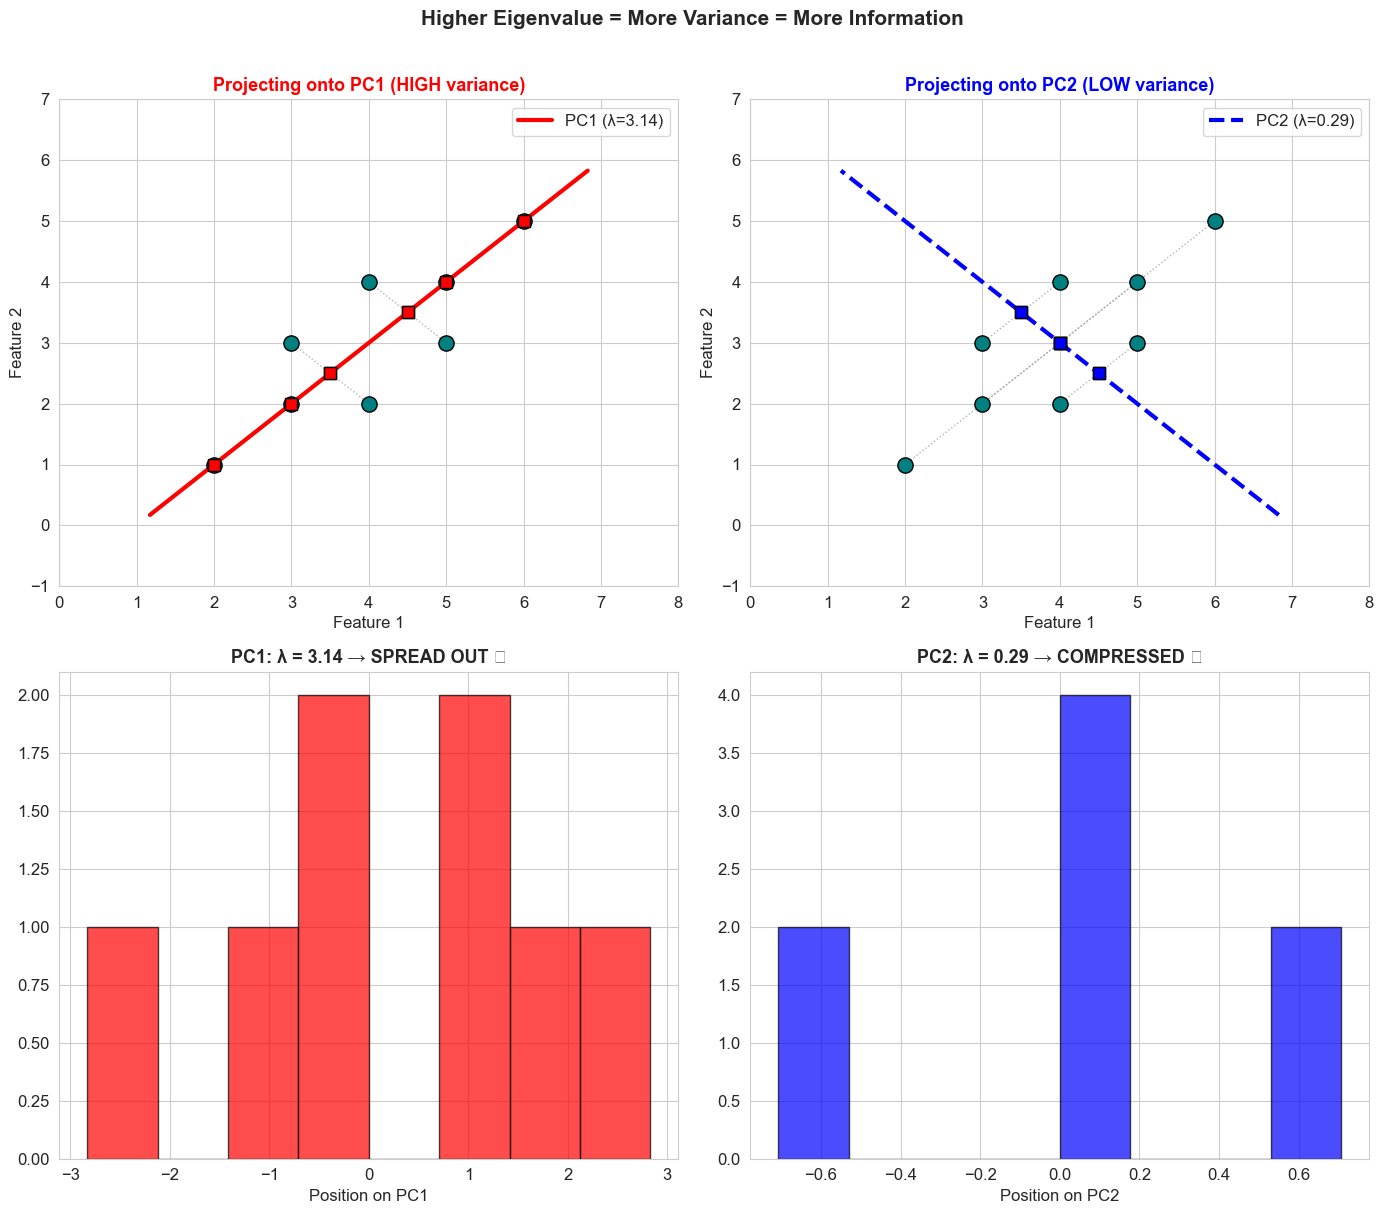

Top plots: circles = original points, squares = where they land on the line
  PC1: points are spread out along the red line → high variance → KEEP
  PC2: points are bunched together on the blue line → low variance → DROP


In [ ]:
# ================================================================
# VISUALIZE: PC1 (high λ) vs PC2 (low λ)
# ================================================================

w1_v = eig_vecs_v[:, 0]
w2_v = eig_vecs_v[:, 1]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Plot 1 (top-left): Project onto PC1 ---
axes[0, 0].scatter(X_verify[:, 0], X_verify[:, 1], c='teal', s=120, edgecolors='k', zorder=5)
t_line = np.linspace(-4, 4, 100)
axes[0, 0].plot(X_mean[0] + t_line*w1_v[0], X_mean[1] + t_line*w1_v[1], 'r-', lw=3, label=f'PC1 (λ={eig_vals_v[0]:.2f})')
# Show projections
for p in X_verify:
    proj_on_line = X_mean + np.dot(p - X_mean, w1_v) * w1_v
    axes[0, 0].plot(*proj_on_line, 's', color='red', markersize=8, markeredgecolor='k', zorder=6)
    axes[0, 0].plot([p[0], proj_on_line[0]], [p[1], proj_on_line[1]],
                   color='gray', lw=1, linestyle=':', alpha=0.6)
axes[0, 0].set_title('Projecting onto PC1 (HIGH variance)', fontsize=13, fontweight='bold', color='red')
axes[0, 0].legend()
axes[0, 0].set_xlabel('Feature 1')
axes[0, 0].set_ylabel('Feature 2')
axes[0, 0].set_xlim(0, 8)
axes[0, 0].set_ylim(-1, 7)

# --- Plot 2 (top-right): Project onto PC2 ---
axes[0, 1].scatter(X_verify[:, 0], X_verify[:, 1], c='teal', s=120, edgecolors='k', zorder=5)
axes[0, 1].plot(X_mean[0] + t_line*w2_v[0], X_mean[1] + t_line*w2_v[1], 'b--', lw=3, label=f'PC2 (λ={eig_vals_v[1]:.2f})')
for p in X_verify:
    proj_on_line = X_mean + np.dot(p - X_mean, w2_v) * w2_v
    axes[0, 1].plot(*proj_on_line, 's', color='blue', markersize=8, markeredgecolor='k', zorder=6)
    axes[0, 1].plot([p[0], proj_on_line[0]], [p[1], proj_on_line[1]],
                   color='gray', lw=1, linestyle=':', alpha=0.6)
axes[0, 1].set_title('Projecting onto PC2 (LOW variance)', fontsize=13, fontweight='bold', color='blue')
axes[0, 1].legend()
axes[0, 1].set_xlabel('Feature 1')
axes[0, 1].set_ylabel('Feature 2')
axes[0, 1].set_xlim(0, 8)
axes[0, 1].set_ylim(-1, 7)

# --- Plot 3 (bottom-left): Histogram on PC1 ---
proj1 = (X_verify - X_mean) @ w1_v
axes[1, 0].hist(proj1, bins=8, alpha=0.7, color='red', edgecolor='black')
axes[1, 0].set_title(f'PC1: λ = {eig_vals_v[0]:.2f} → SPREAD OUT ✅', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Position on PC1')

# --- Plot 4 (bottom-right): Histogram on PC2 ---
proj2 = (X_verify - X_mean) @ w2_v
axes[1, 1].hist(proj2, bins=8, alpha=0.7, color='blue', edgecolor='black')
axes[1, 1].set_title(f'PC2: λ = {eig_vals_v[1]:.2f} → COMPRESSED ❌', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Position on PC2')

plt.suptitle('Higher Eigenvalue = More Variance = More Information', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Top plots: circles = original points, squares = where they land on the line')
print(f'  PC1: points are spread out along the red line → high variance → KEEP')
print(f'  PC2: points are bunched together on the blue line → low variance → DROP')

---
## 5. Solving the Eigenvalue Problem — Getting the Components

### From the Derivation
We showed that maximizing variance leads to:

$$C \mathbf{w} = \lambda \mathbf{w}$$

### How to Solve It
1. **Center** the data (subtract the mean from each feature)
2. Compute the **covariance matrix** $C$ (size $d \times d$)
3. Find its **eigenvalues** $\lambda_1 \geq \lambda_2 \geq \ldots \geq \lambda_d$ and **eigenvectors** $\mathbf{w}_1, \mathbf{w}_2, \ldots, \mathbf{w}_d$
4. Select the top $k$ eigenvectors (corresponding to the $k$ largest eigenvalues)
5. These $k$ eigenvectors form the **projection matrix** $W \in \mathbb{R}^{d \times k}$
6. Transform: $X_{\text{new}} = X_{\text{centered}} \cdot W$

### Important: How Many Components?

Unlike LDA (max $C-1$ components), PCA can give up to $\min(n, d)$ components. But we typically keep far fewer.

The **explained variance ratio** tells you how much variance each component captures:

$$\text{explained variance ratio of PC}_k = \frac{\lambda_k}{\sum_{i=1}^{d} \lambda_i}$$

Common rule: keep enough components to capture **95%** of total variance.

---

Let's solve it step by step:

In [ ]:
# ================================================================
# SOLVING THE EIGENVALUE PROBLEM STEP BY STEP
# ================================================================

# Using the student data from Section 3
print('=' * 60)
print('STEP-BY-STEP PCA ON STUDENT DATA')
print('=' * 60)

data_students = np.array([
    [170, 65, 30],
    [180, 80, 45],
    [160, 55, 25],
    [175, 70, 35],
    [165, 60, 28]
])
feat_names = ['Height', 'Weight', 'Age']

# IMPORTANT: Standardize first (PCA is sensitive to scale!)
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_students)
print(f'\nStep 0 — Standardize (mean=0, std=1 for each feature):')
print(f'  Why? Height is in 100s, Age in 10s. Without scaling, Height dominates.')
print(pd.DataFrame(data_scaled.round(3), columns=feat_names))

# Step 1: Covariance matrix
C_s = np.cov(data_scaled.T)
print(f'\nStep 1 — Covariance matrix C:')
print(pd.DataFrame(C_s.round(4), columns=feat_names, index=feat_names))

# Step 2: Eigenvalues and eigenvectors
eig_vals_s, eig_vecs_s = np.linalg.eig(C_s)
idx = np.argsort(eig_vals_s)[::-1]
eig_vals_s = eig_vals_s[idx].real
eig_vecs_s = eig_vecs_s[:, idx].real

print(f'\nStep 2 — Solve C w = λ w:')
for i in range(len(eig_vals_s)):
    print(f'  PC{i+1}: λ = {eig_vals_s[i]:.4f}, w = {eig_vecs_s[:, i].round(4)}')

# Step 3: Explained variance ratio
evr = eig_vals_s / eig_vals_s.sum()
print(f'\nStep 3 — Explained variance ratio:')
for i in range(len(evr)):
    print(f'  PC{i+1}: {evr[i]*100:.1f}%')
print(f'  Cumulative: {np.cumsum(evr)*100}')

# Step 4: Project (keep top 2 components)
k = 2
W = eig_vecs_s[:, :k]
X_pca = data_scaled @ W

print(f'\nStep 4 — Project onto top {k} components:')
print(f'  Original shape: {data_scaled.shape} (5 students × 3 features)')
print(f'  New shape: {X_pca.shape} (5 students × {k} components)')
print(f'  Variance retained: {evr[:k].sum()*100:.1f}%')

STEP-BY-STEP PCA ON STUDENT DATA

Step 0 — Standardize (mean=0, std=1 for each feature):
  Why? Height is in 100s, Age in 10s. Without scaling, Height dominates.
   Height  Weight    Age
0   0.000  -0.116 -0.371
1   1.414   1.627  1.771
2  -1.414  -1.279 -1.085
3   0.707   0.465  0.343
4  -0.707  -0.697 -0.657

Step 1 — Covariance matrix C:
        Height  Weight     Age
Height  1.2500  1.2330  1.1864
Weight  1.2330  1.2500  1.2326
Age     1.1864  1.2326  1.2500

Step 2 — Solve C w = λ w:
  PC1: λ = 3.6848, w = [-0.575  -0.5822 -0.5749]
  PC2: λ = 0.0636, w = [-0.7054 -0.0033  0.7088]
  PC3: λ = 0.0017, w = [ 0.4146 -0.8131  0.4088]

Step 3 — Explained variance ratio:
  PC1: 98.3%
  PC2: 1.7%
  PC3: 0.0%
  Cumulative: [ 98.26105013  99.95587546 100.        ]

Step 4 — Project onto top 2 components:
  Original shape: (5, 3) (5 students × 3 features)
  New shape: (5, 2) (5 students × 2 components)
  Variance retained: 100.0%


---
## 6. PCA From Scratch

In [ ]:
class PCAFromScratch:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components = None       # eigenvectors (principal directions)
        self.eigenvalues = None       # eigenvalues (variance per component)
        self.mean = None              # mean of training data
        self.explained_variance_ratio = None

    def fit(self, X):
        # Step 1: Center the data
        self.mean = X.mean(axis=0)
        X_centered = X - self.mean

        # Step 2: Compute covariance matrix
        C = np.cov(X_centered.T)

        # Step 3: Solve eigenvalue problem C w = λ w
        eigenvalues, eigenvectors = np.linalg.eig(C)

        # Step 4: Sort by eigenvalue (descending)
        idx = np.argsort(eigenvalues)[::-1]
        eigenvalues = eigenvalues[idx].real
        eigenvectors = eigenvectors[:, idx].real

        # Step 5: Keep top k
        self.eigenvalues = eigenvalues[:self.n_components]
        self.components = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio = self.eigenvalues / eigenvalues.sum()

        return self

    def transform(self, X):
        # Center using training mean, then project
        X_centered = X - self.mean
        return X_centered @ self.components

    def fit_transform(self, X):
        self.fit(X)
        return self.transform(X)

# Test it
iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Our implementation
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

pca_scratch = PCAFromScratch(n_components=2)
X_scratch = pca_scratch.fit_transform(X_iris_scaled)

# sklearn implementation
pca_sklearn = PCA(n_components=2)
X_sklearn = pca_sklearn.fit_transform(X_iris_scaled)

print('PCA From Scratch vs sklearn:')
print(f'  Our eigenvalues:    {pca_scratch.eigenvalues.round(4)}')
print(f'  sklearn eigenvalues: {pca_sklearn.explained_variance_.round(4)}')
print(f'\n  Our explained var ratio:    {pca_scratch.explained_variance_ratio.round(4)}')
print(f'  sklearn explained var ratio: {pca_sklearn.explained_variance_ratio_.round(4)}')
print(f'\n  Results match (up to sign): {np.allclose(np.abs(X_scratch), np.abs(X_sklearn))} ✅')

PCA From Scratch vs sklearn:
  Our eigenvalues:    [2.9381 0.9202]
  sklearn eigenvalues: [2.9381 0.9202]

  Our explained var ratio:    [0.7296 0.2285]
  sklearn explained var ratio: [0.7296 0.2285]

  Results match (up to sign): True ✅


---
## 7. Projection Visualization — What PCA Actually Does

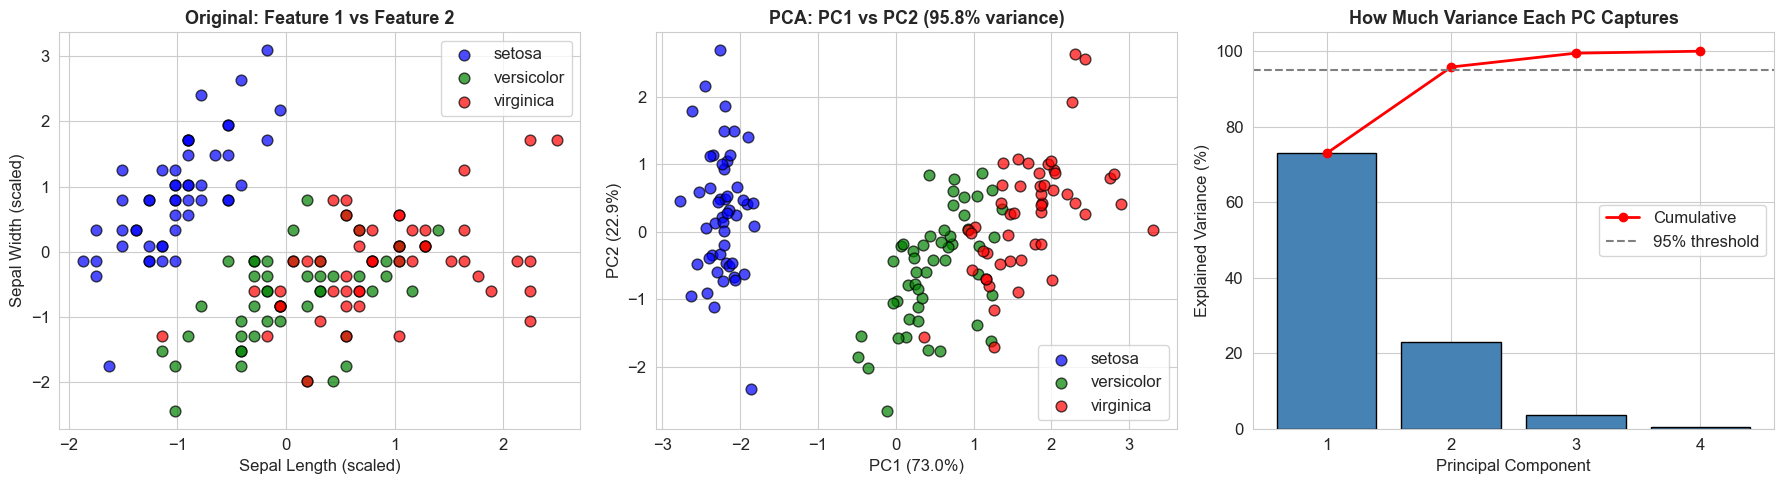

Iris has 4 features, but 2 PCs capture 95.8% of variance.
We reduced features by 50% and lost almost nothing.


In [ ]:
# ================================================================
# VISUALIZE: Iris 4D → 2D with PCA
# ================================================================

colors = ['blue', 'green', 'red']
target_names = iris.target_names

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Original features (first two)
for i, (color, name) in enumerate(zip(colors, target_names)):
    mask = y_iris == i
    axes[0].scatter(X_iris_scaled[mask, 0], X_iris_scaled[mask, 1], c=color, label=name, alpha=0.7, edgecolors='k', s=60)
axes[0].set_title('Original: Feature 1 vs Feature 2', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sepal Length (scaled)')
axes[0].set_ylabel('Sepal Width (scaled)')
axes[0].legend()

# Plot 2: PCA 2D
X_pca_iris = pca_sklearn.fit_transform(X_iris_scaled)
for i, (color, name) in enumerate(zip(colors, target_names)):
    mask = y_iris == i
    axes[1].scatter(X_pca_iris[mask, 0], X_pca_iris[mask, 1], c=color, label=name, alpha=0.7, edgecolors='k', s=60)
axes[1].set_title(f'PCA: PC1 vs PC2 ({pca_sklearn.explained_variance_ratio_.sum()*100:.1f}% variance)', fontsize=13, fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_sklearn.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_sklearn.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].legend()

# Plot 3: Explained variance
pca_full = PCA().fit(X_iris_scaled)
axes[2].bar(range(1, 5), pca_full.explained_variance_ratio_ * 100, color='steelblue', edgecolor='black')
axes[2].plot(range(1, 5), np.cumsum(pca_full.explained_variance_ratio_) * 100, 'ro-', lw=2, label='Cumulative')
axes[2].axhline(y=95, color='gray', linestyle='--', label='95% threshold')
axes[2].set_xlabel('Principal Component')
axes[2].set_ylabel('Explained Variance (%)')
axes[2].set_title('How Much Variance Each PC Captures', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].set_xticks(range(1, 5))

plt.tight_layout()
plt.show()

print(f'Iris has 4 features, but 2 PCs capture {pca_sklearn.explained_variance_ratio_.sum()*100:.1f}% of variance.')
print(f'We reduced features by 50% and lost almost nothing.')

---
## 8. Explained Variance Ratio — How to Choose Number of Components

The most important practical question: **how many components to keep?**

Three approaches:
1. **Cumulative variance threshold** — keep enough PCs to capture 90-95% of variance
2. **Elbow method** — look for a "bend" in the scree plot
3. **Cross-validation** — try different numbers and measure actual model performance

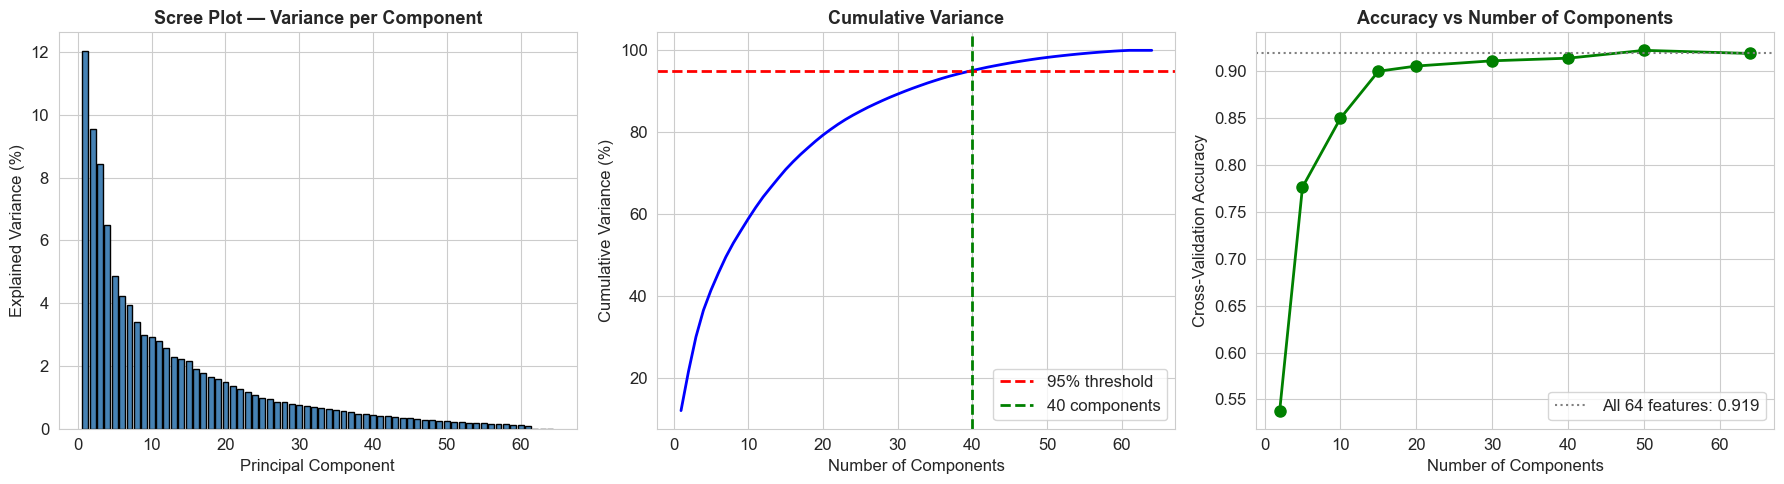

Digits dataset: 64 features → 40 PCs capture 95% of variance
Accuracy with 40 PCs: 0.914
Accuracy with all 64 features: 0.919

→ We can drop ~24 features and barely lose any accuracy!


In [ ]:
# ================================================================
# CHOOSING NUMBER OF COMPONENTS — DIGITS DATASET (64 features)
# ================================================================

digits = load_digits()
X_dig = digits.data
y_dig = digits.target

scaler_dig = StandardScaler()
X_dig_scaled = scaler_dig.fit_transform(X_dig)

# Fit PCA with all components
pca_all = PCA().fit(X_dig_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Scree plot (individual variance)
axes[0].bar(range(1, 65), pca_all.explained_variance_ratio_ * 100, color='steelblue', edgecolor='black')
axes[0].set_title('Scree Plot — Variance per Component', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')

# Plot 2: Cumulative variance
cumvar = np.cumsum(pca_all.explained_variance_ratio_) * 100
axes[1].plot(range(1, 65), cumvar, 'b-', lw=2)
axes[1].axhline(y=95, color='red', linestyle='--', lw=2, label='95% threshold')
n_95 = np.argmax(cumvar >= 95) + 1
axes[1].axvline(x=n_95, color='green', linestyle='--', lw=2, label=f'{n_95} components')
axes[1].set_title('Cumulative Variance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

# Plot 3: Accuracy vs number of components
n_range = [2, 5, 10, 15, 20, 30, 40, 50, 64]
accs = []
for n in n_range:
    pca_temp = PCA(n_components=n)
    X_temp = pca_temp.fit_transform(X_dig_scaled)
    scores = cross_val_score(LogisticRegression(max_iter=1000), X_temp, y_dig, cv=5)
    accs.append(scores.mean())

axes[2].plot(n_range, accs, 'go-', lw=2, markersize=8)
axes[2].set_title('Accuracy vs Number of Components', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Number of Components')
axes[2].set_ylabel('Cross-Validation Accuracy')
axes[2].axhline(y=accs[-1], color='gray', linestyle=':', label=f'All 64 features: {accs[-1]:.3f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Digits dataset: 64 features → {n_95} PCs capture 95% of variance')
print(f'Accuracy with {n_95} PCs: {accs[n_range.index(min(n_range, key=lambda x: abs(x-n_95)))]:.3f}')
print(f'Accuracy with all 64 features: {accs[-1]:.3f}')
print(f'\n→ We can drop ~{64-n_95} features and barely lose any accuracy!')

---
## 9. Real Dataset — Iris (4D → 2D)

Iris — PCA Results:
  Original features: 4
  PCA components: 2
  Variance retained: 95.8%
  Accuracy: 88.9%

PC1 = +0.521×sepal length (cm)  -0.269×sepal width (cm)  +0.580×petal length (cm)  +0.565×petal width (cm)  
PC2 = +0.377×sepal length (cm)  +0.923×sepal width (cm)  +0.024×petal length (cm)  +0.067×petal width (cm)  

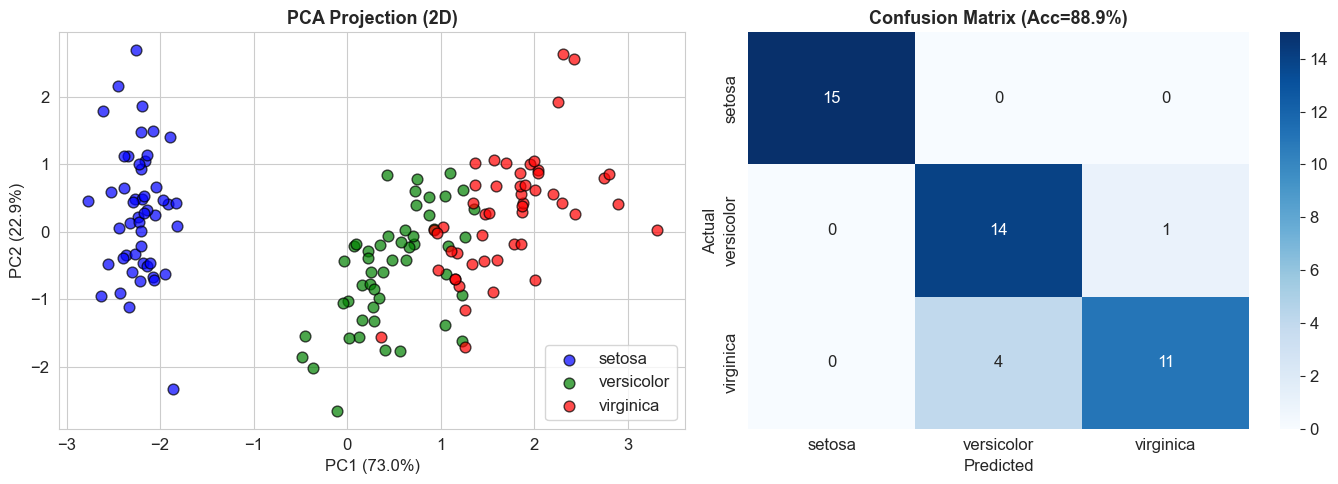

In [ ]:
# ================================================================
# END-TO-END: PCA on Iris dataset
# ================================================================

iris = load_iris()
X_iris, y_iris = iris.data, iris.target

# Step 1: Scale
scaler_i = StandardScaler()
X_scaled_i = scaler_i.fit_transform(X_iris)

# Step 2: PCA
pca_iris = PCA(n_components=2)
X_pca_i = pca_iris.fit_transform(X_scaled_i)

# Step 3: Train/test split
X_tr, X_te, y_tr, y_te = train_test_split(X_pca_i, y_iris, test_size=0.3, random_state=42, stratify=y_iris)

# Step 4: Classify
clf_i = LogisticRegression(max_iter=1000)
clf_i.fit(X_tr, y_tr)
y_pred_i = clf_i.predict(X_te)

print(f'Iris — PCA Results:')
print(f'  Original features: {X_iris.shape[1]}')
print(f'  PCA components: 2')
print(f'  Variance retained: {pca_iris.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  Accuracy: {accuracy_score(y_te, y_pred_i)*100:.1f}%')

# What each PC is made of
print(f'\nPC1 = ', end='')
for j, name in enumerate(iris.feature_names):
    sign = '+' if pca_iris.components_[0, j] >= 0 else ''
    print(f'{sign}{pca_iris.components_[0, j]:.3f}×{name}  ', end='')
print(f'\nPC2 = ', end='')
for j, name in enumerate(iris.feature_names):
    sign = '+' if pca_iris.components_[1, j] >= 0 else ''
    print(f'{sign}{pca_iris.components_[1, j]:.3f}×{name}  ', end='')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_i = ['blue', 'green', 'red']
for i, (c, name) in enumerate(zip(colors_i, iris.target_names)):
    mask = y_iris == i
    axes[0].scatter(X_pca_i[mask, 0], X_pca_i[mask, 1], c=c, label=name, alpha=0.7, edgecolors='k', s=60)
axes[0].set_title('PCA Projection (2D)', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_iris.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_iris.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Confusion matrix
cm_i = confusion_matrix(y_te, y_pred_i)
sns.heatmap(cm_i, annot=True, fmt='d', cmap='Blues', xticklabels=iris.target_names, yticklabels=iris.target_names, ax=axes[1])
axes[1].set_title(f'Confusion Matrix (Acc={accuracy_score(y_te, y_pred_i)*100:.1f}%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

---
## 10. Real Dataset — Breast Cancer (30D → 2D)

Breast Cancer Dataset:
  Features: 30 → 2 PCs
  Variance retained: 64.8%
  Accuracy with 2 PCs:     94.7%
  Accuracy with all 30 features: 98.8%


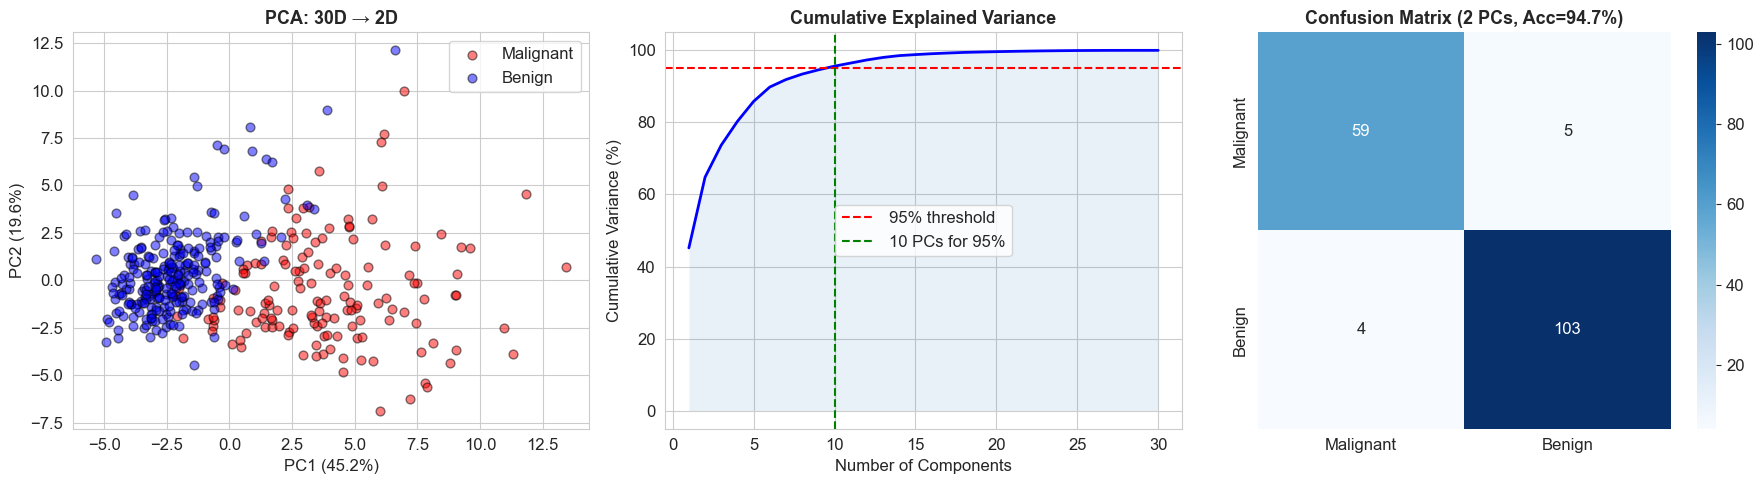


→ 30 features → 2 PCs: dropped 93% of features, lost only 4.1% accuracy
→ For 95% variance: need only 10 out of 30 features

CONFUSION MATRIX: All 30 Features

Confusion Matrix (All 30 features):
[[ 63   1]
 [  1 106]]

Accuracy with all features: 98.8%


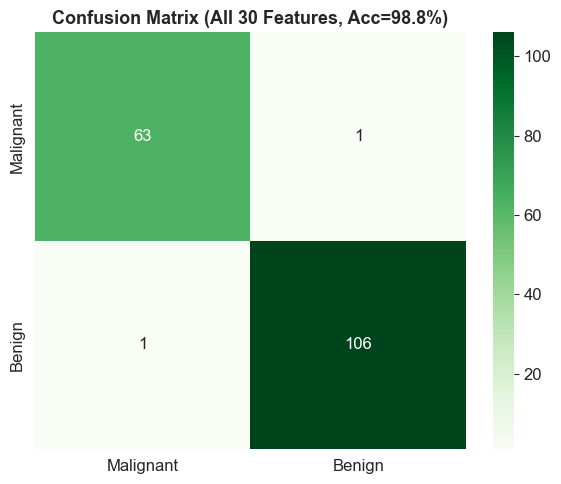

In [ ]:
# ================================================================
# END-TO-END: PCA on Breast Cancer dataset
# ================================================================

# Load data
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

# Train-test split FIRST (avoid data leakage)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_cancer, y_cancer, test_size=0.3, random_state=42, stratify=y_cancer)


# Standardize — fit on training data only, transform both
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# PCA on scaled training data
pca_cancer = PCA(n_components=2)
X_train_c_scaled_pca = pca_cancer.fit_transform(X_train_c_scaled)
X_test_c_scaled_pca = pca_cancer.transform(X_test_c_scaled)


# Classify using only the 2 PCs
clf_c = LogisticRegression(random_state=42)
clf_c.fit(X_train_c_scaled_pca, y_train_c)
y_pred_c = clf_c.predict(X_test_c_scaled_pca)


clf_all = LogisticRegression(random_state=42)
clf_all.fit(X_train_c_scaled, y_train_c)
y_pred_all = clf_all.predict(X_test_c_scaled)

print(f'Breast Cancer Dataset:')
print(f'  Features: {X_cancer.shape[1]} → 2 PCs')
print(f'  Variance retained: {pca_cancer.explained_variance_ratio_.sum()*100:.1f}%')
print(f'  Accuracy with 2 PCs:     {accuracy_score(y_test_c, y_pred_c)*100:.1f}%')
print(f'  Accuracy with all 30 features: {accuracy_score(y_test_c, y_pred_all)*100:.1f}%')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# PCA projection
for label, color, name in [(0, 'red', 'Malignant'), (1, 'blue', 'Benign')]:
    mask = y_train_c == label
    axes[0].scatter(X_train_c_scaled_pca[mask, 0], X_train_c_scaled_pca[mask, 1], c=color, label=name, alpha=0.5, edgecolors='k', s=40)
axes[0].set_title('PCA: 30D → 2D', fontsize=13, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_cancer.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca_cancer.explained_variance_ratio_[1]*100:.1f}%)')
axes[0].legend()

# Explained variance
pca_all_c = PCA().fit(X_train_c_scaled)
cumvar_c = np.cumsum(pca_all_c.explained_variance_ratio_) * 100
axes[1].plot(range(1, 31), cumvar_c, 'b-', lw=2)
axes[1].axhline(y=95, color='red', linestyle='--', label='95% threshold')
n95_c = np.argmax(cumvar_c >= 95) + 1
axes[1].axvline(x=n95_c, color='green', linestyle='--', label=f'{n95_c} PCs for 95%')
axes[1].fill_between(range(1, 31), cumvar_c, alpha=0.1)
axes[1].set_title('Cumulative Explained Variance', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

# Confusion matrix (2 PCs)
cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Blues', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'], ax=axes[2])
axes[2].set_title(f'Confusion Matrix (2 PCs, Acc={accuracy_score(y_test_c, y_pred_c)*100:.1f}%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\n→ 30 features → 2 PCs: dropped 93% of features, lost only {accuracy_score(y_test_c, y_pred_all)*100 - accuracy_score(y_test_c, y_pred_c)*100:.1f}% accuracy')
print(f'→ For 95% variance: need only {n95_c} out of 30 features')

# Confusion matrix for all features
print(f'\n{"="*60}')
print(f'CONFUSION MATRIX: All 30 Features')
print(f'{"="*60}')
cm_all = confusion_matrix(y_test_c, y_pred_all)
print(f'\nConfusion Matrix (All 30 features):')
print(cm_all)
print(f'\nAccuracy with all features: {accuracy_score(y_test_c, y_pred_all)*100:.1f}%')

# Visualize
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm_all, annot=True, fmt='d', cmap='Greens', xticklabels=['Malignant', 'Benign'], yticklabels=['Malignant', 'Benign'], ax=ax)
ax.set_title(f'Confusion Matrix (All 30 Features, Acc={accuracy_score(y_test_c, y_pred_all)*100:.1f}%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


ACCURACY IMPROVEMENT: Varying Number of Principal Components (1-10)

PCs:  1 | Variance Retained:  45.16% | Accuracy:  91.23%
PCs:  2 | Variance Retained:  64.78% | Accuracy:  94.74%
PCs:  3 | Variance Retained:  73.68% | Accuracy:  92.98%
PCs:  4 | Variance Retained:  80.28% | Accuracy:  95.32%
PCs:  5 | Variance Retained:  85.82% | Accuracy:  97.66%
PCs:  6 | Variance Retained:  89.82% | Accuracy:  97.66%
PCs:  7 | Variance Retained:  91.89% | Accuracy:  95.91%
PCs:  8 | Variance Retained:  93.41% | Accuracy:  96.49%
PCs:  9 | Variance Retained:  94.58% | Accuracy:  97.66%
PCs: 10 | Variance Retained:  95.62% | Accuracy:  97.08%


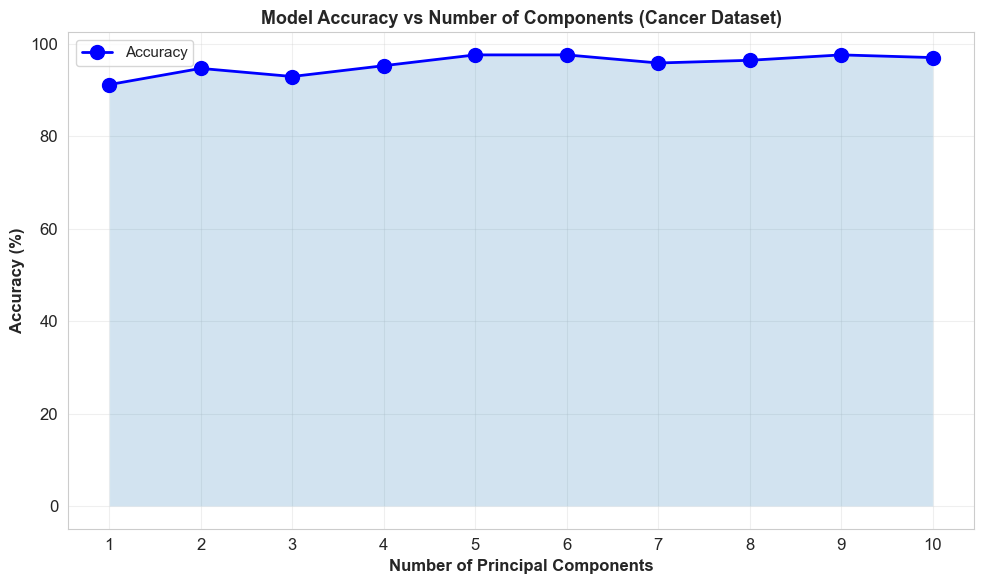


KEY INSIGHT: Even with just 1 to 10 PCs, we achieve competitive accuracy!


In [ ]:
# ================================================================
# PCA: Model Accuracy vs Number of Components (1 to 10)
# ================================================================

print(f"\n{'='*70}")
print(f"ACCURACY IMPROVEMENT: Varying Number of Principal Components (1-10)")
print(f"{'='*70}\n")

accuracies = []
pc_range = range(1, 11)

for n_pc in pc_range:
    # Apply PCA with n_pc components on TRAINING data only
    pca_temp = PCA(n_components=n_pc)
    X_tr_pca_temp = pca_temp.fit_transform(X_train_c_scaled)
    X_te_pca_temp = pca_temp.transform(X_test_c_scaled)  # Transform test data with same PCA

    # Train classifier on PCA-reduced data
    clf_temp = LogisticRegression(max_iter=1000)
    clf_temp.fit(X_tr_pca_temp, y_train_c)
    y_pred_temp = clf_temp.predict(X_te_pca_temp)

    # Calculate accuracy
    acc = accuracy_score(y_test_c, y_pred_temp) * 100
    var_retained = np.sum(pca_temp.explained_variance_ratio_) * 100

    accuracies.append(acc)

    print(f"PCs: {n_pc:2d} | Variance Retained: {var_retained:6.2f}% | Accuracy: {acc:6.2f}%")

# Plot accuracy vs number of components
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(pc_range, accuracies, 'bo-', linewidth=2, markersize=10, label='Accuracy')
ax.fill_between(pc_range, accuracies, alpha=0.2)
ax.set_xlabel('Number of Principal Components', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy vs Number of Components (Cancer Dataset)', fontsize=13, fontweight='bold')
ax.set_xticks(pc_range)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"KEY INSIGHT: Even with just 1 to {pc_range[-1]} PCs, we achieve competitive accuracy!")
print(f"{'='*70}")

---
## 11. Real Dataset — Digits (64D → Reduced)

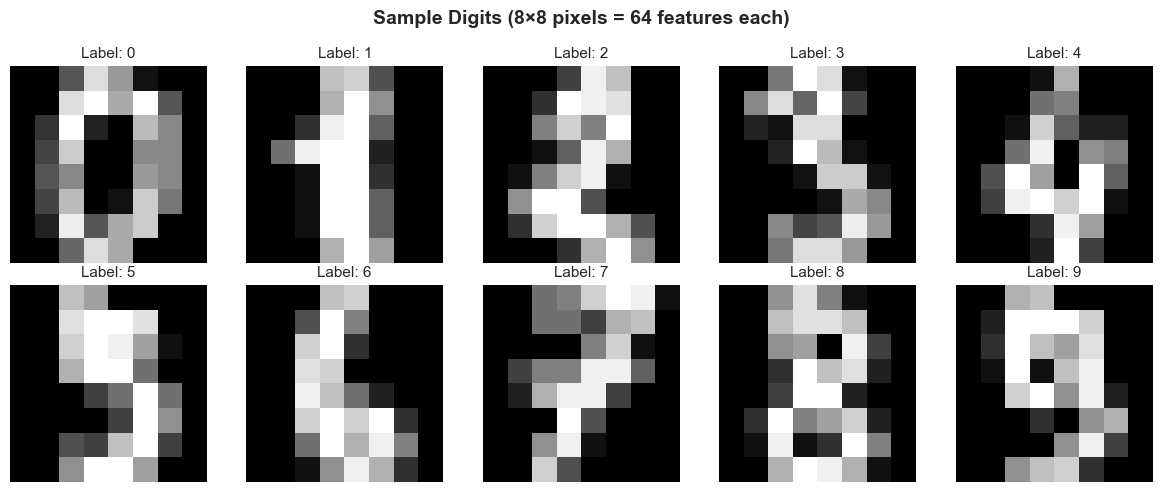

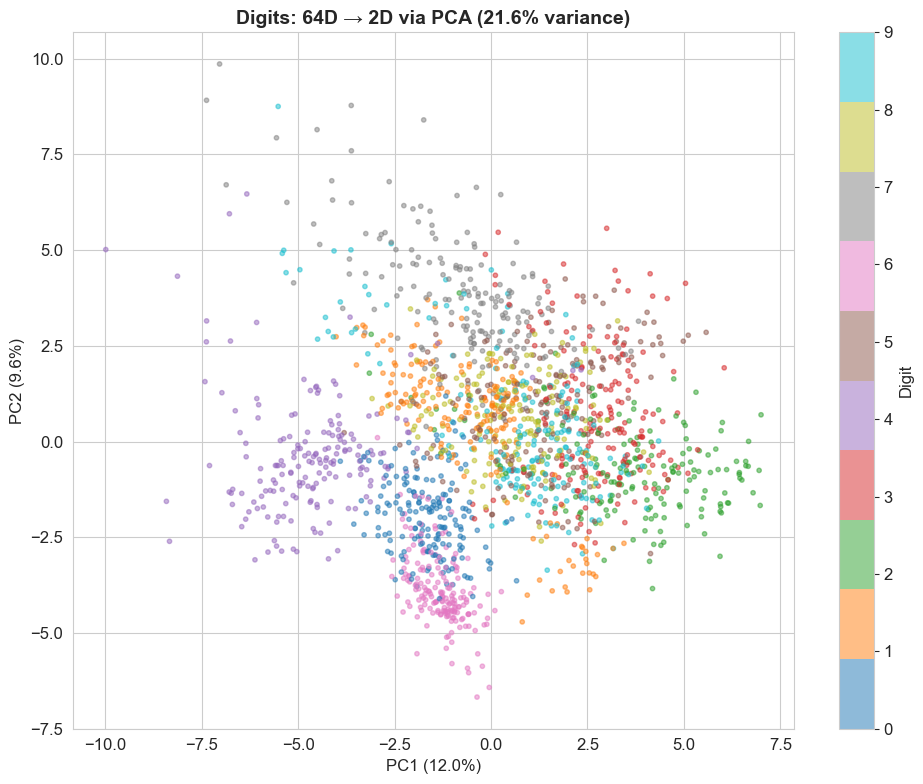


Digits: Accuracy vs Number of Components
 Components Variance (%) Accuracy (%) Train Time (ms)
          2         21.6         54.3            20.8
          5         41.4         80.4            28.0
         10         58.9         88.0            24.8
         20         79.3         93.7            23.0
         30         89.3         96.3            21.6
         64        100.0         97.0            19.6


In [ ]:
# ================================================================
# END-TO-END: PCA on Digits dataset (8x8 images, 64 features)
# ================================================================

digits = load_digits()
X_d, y_d = digits.data, digits.target

scaler_d = StandardScaler()
X_d_scaled = scaler_d.fit_transform(X_d)

# Show some sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y_d[i]}', fontsize=11)
    ax.axis('off')
plt.suptitle('Sample Digits (8×8 pixels = 64 features each)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# PCA to 2D for visualization
pca_d2 = PCA(n_components=2)
X_d_2d = pca_d2.fit_transform(X_d_scaled)

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_d_2d[:, 0], X_d_2d[:, 1], c=y_d, cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Digit')
plt.title(f'Digits: 64D → 2D via PCA ({pca_d2.explained_variance_ratio_.sum()*100:.1f}% variance)', fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_d2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_d2.explained_variance_ratio_[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

# Compare accuracy with different numbers of components
results = []
for n in [2, 5, 10, 20, 30, 64]:
    pca_n = PCA(n_components=min(n, 64))
    X_n = pca_n.fit_transform(X_d_scaled)
    X_tr_d, X_te_d, y_tr_d, y_te_d = train_test_split(X_n, y_d, test_size=0.3, random_state=42)

    start = time.time()
    clf_d = LogisticRegression(max_iter=1000)
    clf_d.fit(X_tr_d, y_tr_d)
    train_time = time.time() - start

    acc = accuracy_score(y_te_d, clf_d.predict(X_te_d))
    var = pca_n.explained_variance_ratio_.sum() * 100
    results.append({'Components': n, 'Variance (%)': f'{var:.1f}', 'Accuracy (%)': f'{acc*100:.1f}', 'Train Time (ms)': f'{train_time*1000:.1f}'})

df_results = pd.DataFrame(results)
print('\nDigits: Accuracy vs Number of Components')
print(df_results.to_string(index=False))

---
## 12. sklearn Pipeline — Production-Ready PCA

In [ ]:
# ================================================================
# SKLEARN PIPELINE: Scale → PCA → Classify in one step
# ================================================================

wine = load_wine()
X_wine, y_wine = wine.data, wine.target

X_tr_w, X_te_w, y_tr_w, y_te_w = train_test_split(X_wine, y_wine, test_size=0.3, random_state=42, stratify=y_wine)

# Pipeline WITHOUT PCA
pipe_no_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000))
])

# Pipeline WITH PCA
pipe_pca = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95)),  # keep 95% variance automatically!
    ('clf', LogisticRegression(max_iter=1000))
])

# Train and evaluate both
pipe_no_pca.fit(X_tr_w, y_tr_w)
pipe_pca.fit(X_tr_w, y_tr_w)

acc_no_pca = accuracy_score(y_te_w, pipe_no_pca.predict(X_te_w))
acc_pca = accuracy_score(y_te_w, pipe_pca.predict(X_te_w))

pca_step = pipe_pca.named_steps['pca']
print(f'Wine Dataset (13 features):')
print(f'  Without PCA: accuracy = {acc_no_pca*100:.1f}%, features = 13')
print(f'  With PCA:    accuracy = {acc_pca*100:.1f}%, features = {pca_step.n_components_}')
print(f'  Variance retained: {pca_step.explained_variance_ratio_.sum()*100:.1f}%')
print(f'\nTip: PCA(n_components=0.95) automatically picks enough components for 95% variance.')

# Cross-validation comparison
cv_no_pca = cross_val_score(pipe_no_pca, X_wine, y_wine, cv=5)
cv_pca = cross_val_score(pipe_pca, X_wine, y_wine, cv=5)
print(f'\nCross-validation (5-fold):')
print(f'  Without PCA: {cv_no_pca.mean()*100:.1f}% ± {cv_no_pca.std()*100:.1f}%')
print(f'  With PCA:    {cv_pca.mean()*100:.1f}% ± {cv_pca.std()*100:.1f}%')

Wine Dataset (13 features):
  Without PCA: accuracy = 98.1%, features = 13
  With PCA:    accuracy = 98.1%, features = 10
  Variance retained: 96.5%

Tip: PCA(n_components=0.95) automatically picks enough components for 95% variance.

Cross-validation (5-fold):
  Without PCA: 98.3% ± 1.4%
  With PCA:    98.3% ± 2.2%


---
## 13. PCA vs No PCA — Speed, Accuracy, Overfitting

In [ ]:
# ================================================================
# COMPARISON: PCA vs No PCA across multiple classifiers
# ================================================================

# Generate a high-dimensional dataset
X_hd, y_hd = make_classification(n_samples=1000, n_features=50, n_informative=10,
                                  n_redundant=30, n_classes=3, n_clusters_per_class=1,
                                  random_state=42)

scaler_hd = StandardScaler()
X_hd_scaled = scaler_hd.fit_transform(X_hd)

# PCA keeping 95% variance
pca_hd = PCA(n_components=0.95)
X_hd_pca = pca_hd.fit_transform(X_hd_scaled)
print(f'Original: {X_hd_scaled.shape[1]} features → PCA: {X_hd_pca.shape[1]} components (95% variance)')

X_tr_hd, X_te_hd, y_tr_hd, y_te_hd = train_test_split(X_hd_scaled, y_hd, test_size=0.3, random_state=42)
X_tr_pca, X_te_pca, _, _ = train_test_split(X_hd_pca, y_hd, test_size=0.3, random_state=42)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results_list = []
for name, clf in classifiers.items():
    # Without PCA
    start = time.time()
    clf.fit(X_tr_hd, y_tr_hd)
    time_no = time.time() - start
    acc_train_no = accuracy_score(y_tr_hd, clf.predict(X_tr_hd))
    acc_test_no = accuracy_score(y_te_hd, clf.predict(X_te_hd))

    # With PCA
    import copy
    clf2 = copy.deepcopy(clf) if hasattr(clf, '__deepcopy__') else type(clf)(**clf.get_params())
    start = time.time()
    clf2.fit(X_tr_pca, y_tr_hd)
    time_pca = time.time() - start
    acc_train_pca = accuracy_score(y_tr_hd, clf2.predict(X_tr_pca))
    acc_test_pca = accuracy_score(y_te_hd, clf2.predict(X_te_pca))

    results_list.append({
        'Classifier': name,
        'No PCA Train': f'{acc_train_no*100:.1f}%',
        'No PCA Test': f'{acc_test_no*100:.1f}%',
        'No PCA Gap': f'{(acc_train_no-acc_test_no)*100:.1f}%',
        'PCA Train': f'{acc_train_pca*100:.1f}%',
        'PCA Test': f'{acc_test_pca*100:.1f}%',
        'PCA Gap': f'{(acc_train_pca-acc_test_pca)*100:.1f}%',
        'Speedup': f'{time_no/max(time_pca, 1e-6):.1f}x'
    })

df_comp = pd.DataFrame(results_list)
print('\n50 features → PCA (95% variance):')
print(df_comp.to_string(index=False))
print('\nGap = Train - Test accuracy (lower = less overfitting)')

Original: 50 features → PCA: 18 components (95% variance)

50 features → PCA (95% variance):
         Classifier No PCA Train No PCA Test No PCA Gap PCA Train PCA Test PCA Gap Speedup
Logistic Regression        94.0%       93.0%       1.0%     93.9%    91.3%    2.5%    1.3x
                KNN        95.9%       92.0%       3.9%     95.9%    90.3%    5.5%    1.0x
      Decision Tree       100.0%       84.3%      15.7%    100.0%    81.0%   19.0%    3.0x
                SVM        98.4%       95.3%       3.1%     98.0%    95.3%    2.7%    1.2x
      Random Forest       100.0%       93.3%       6.7%    100.0%    93.0%    7.0%    1.3x

Gap = Train - Test accuracy (lower = less overfitting)


---
## 14. When PCA Fails — Assumptions and Limitations

PCA assumes:

### 1. Features Should Be Scaled
PCA finds directions of maximum **variance**. If one feature is in thousands (e.g., salary) and another is 0-1 (e.g., probability), the large-scale feature will dominate PC1 regardless of importance.

**Fix:** Always standardize (mean=0, std=1) before PCA.

### 2. Variance = Information
PCA assumes that directions with high variance are important. This is NOT always true:
- A noisy feature can have high variance but carry zero useful information
- A low-variance feature might be the most important for classification

### 3. Linear Relationships
PCA only captures **linear** patterns. If the data has a curved/nonlinear structure (like a spiral), PCA cannot find it.

**Fix:** Use Kernel PCA for nonlinear data.

### 4. No Class Information
PCA is **unsupervised** — it doesn't know about labels. The direction of maximum variance might NOT be the direction that separates classes best.

**Fix:** Use LDA when you have labels and want to classify.

### 5. Orthogonal Components
PCA forces all components to be perpendicular to each other. This is a mathematical convenience, not always what the data wants.

---

Let's see each failure in action:

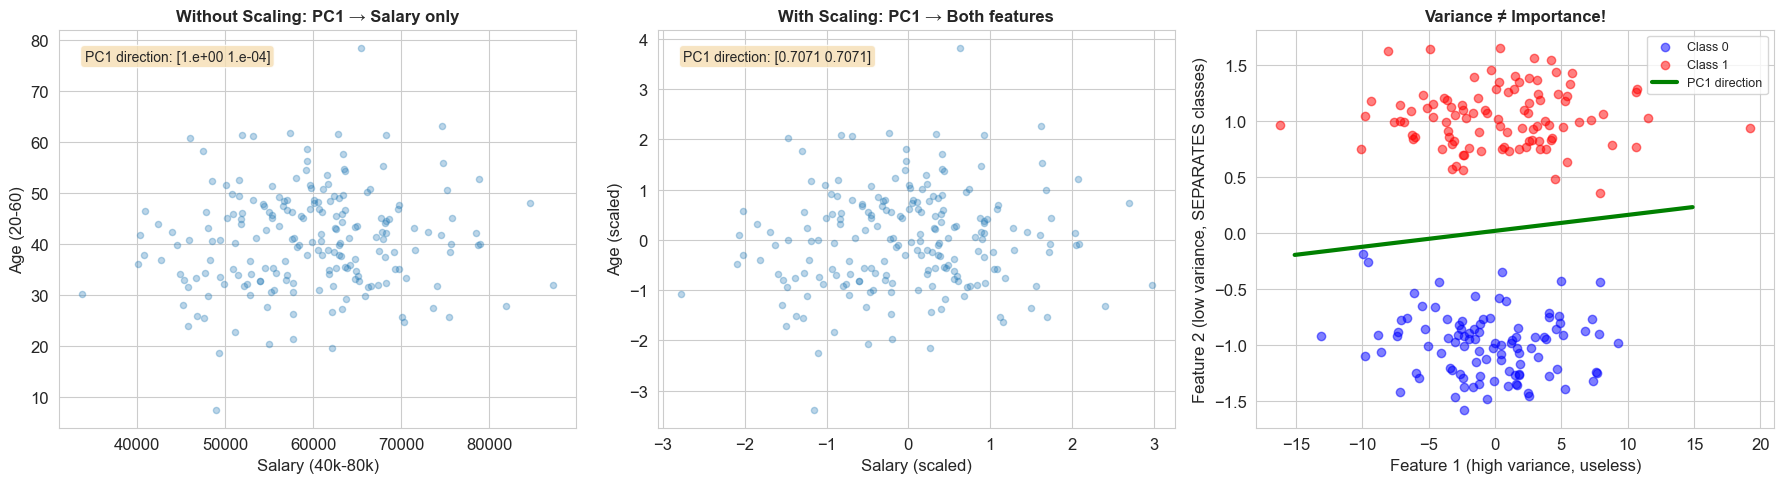

Plot 1: Without scaling, PC1 = [1.0000, 0.0000] → only captures salary, ignores age
Plot 2: With scaling, PC1 uses both features → correct
Plot 3: PC1 goes HORIZONTAL (high variance) but classes are separated VERTICALLY (low variance)
        → PCA picks the WRONG direction for classification! Use LDA instead.


In [ ]:
# ================================================================
# FAILURE 1: Scaling matters
# FAILURE 2: Variance ≠ importance
# ================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Failure 1: Without scaling ---
np.random.seed(42)
# Feature 1: salary (40000-80000), Feature 2: age (20-60)
X_scale = np.column_stack([
    np.random.normal(60000, 10000, 200),
    np.random.normal(40, 10, 200)
])

pca_noscale = PCA(n_components=1).fit(X_scale)
pca_scaled = PCA(n_components=1).fit(StandardScaler().fit_transform(X_scale))

axes[0].scatter(X_scale[:, 0], X_scale[:, 1], alpha=0.3, s=20)
axes[0].set_title('Without Scaling: PC1 → Salary only', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Salary (40k-80k)')
axes[0].set_ylabel('Age (20-60)')
axes[0].annotate(f'PC1 direction: {pca_noscale.components_[0].round(4)}', xy=(0.05, 0.95),
                xycoords='axes fraction', fontsize=10, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

X_sc = StandardScaler().fit_transform(X_scale)
axes[1].scatter(X_sc[:, 0], X_sc[:, 1], alpha=0.3, s=20)
axes[1].set_title('With Scaling: PC1 → Both features', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Salary (scaled)')
axes[1].set_ylabel('Age (scaled)')
axes[1].annotate(f'PC1 direction: {pca_scaled.components_[0].round(4)}', xy=(0.05, 0.95),
                xycoords='axes fraction', fontsize=10, va='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

# --- Failure 2: Variance ≠ importance ---
np.random.seed(42)
# Class 0 and Class 1 differ in Feature 2 (low variance), not Feature 1 (high variance)
n_pts = 100
X_f = np.vstack([
    np.column_stack([np.random.normal(0, 5, n_pts), np.random.normal(-1, 0.3, n_pts)]),
    np.column_stack([np.random.normal(0, 5, n_pts), np.random.normal(1, 0.3, n_pts)])
])
y_f = np.array([0]*n_pts + [1]*n_pts)

axes[2].scatter(X_f[y_f==0, 0], X_f[y_f==0, 1], c='blue', alpha=0.5, label='Class 0')
axes[2].scatter(X_f[y_f==1, 0], X_f[y_f==1, 1], c='red', alpha=0.5, label='Class 1')
pca_f = PCA(n_components=1).fit(X_f)
center_f = X_f.mean(axis=0)
t_f = np.linspace(-15, 15, 100)
axes[2].plot(center_f[0] + t_f*pca_f.components_[0, 0], center_f[1] + t_f*pca_f.components_[0, 1],
            'g-', lw=3, label='PC1 direction')
axes[2].set_title('Variance ≠ Importance!', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Feature 1 (high variance, useless)')
axes[2].set_ylabel('Feature 2 (low variance, SEPARATES classes)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Plot 1: Without scaling, PC1 = [1.0000, 0.0000] → only captures salary, ignores age')
print('Plot 2: With scaling, PC1 uses both features → correct')
print('Plot 3: PC1 goes HORIZONTAL (high variance) but classes are separated VERTICALLY (low variance)')
print('        → PCA picks the WRONG direction for classification! Use LDA instead.')

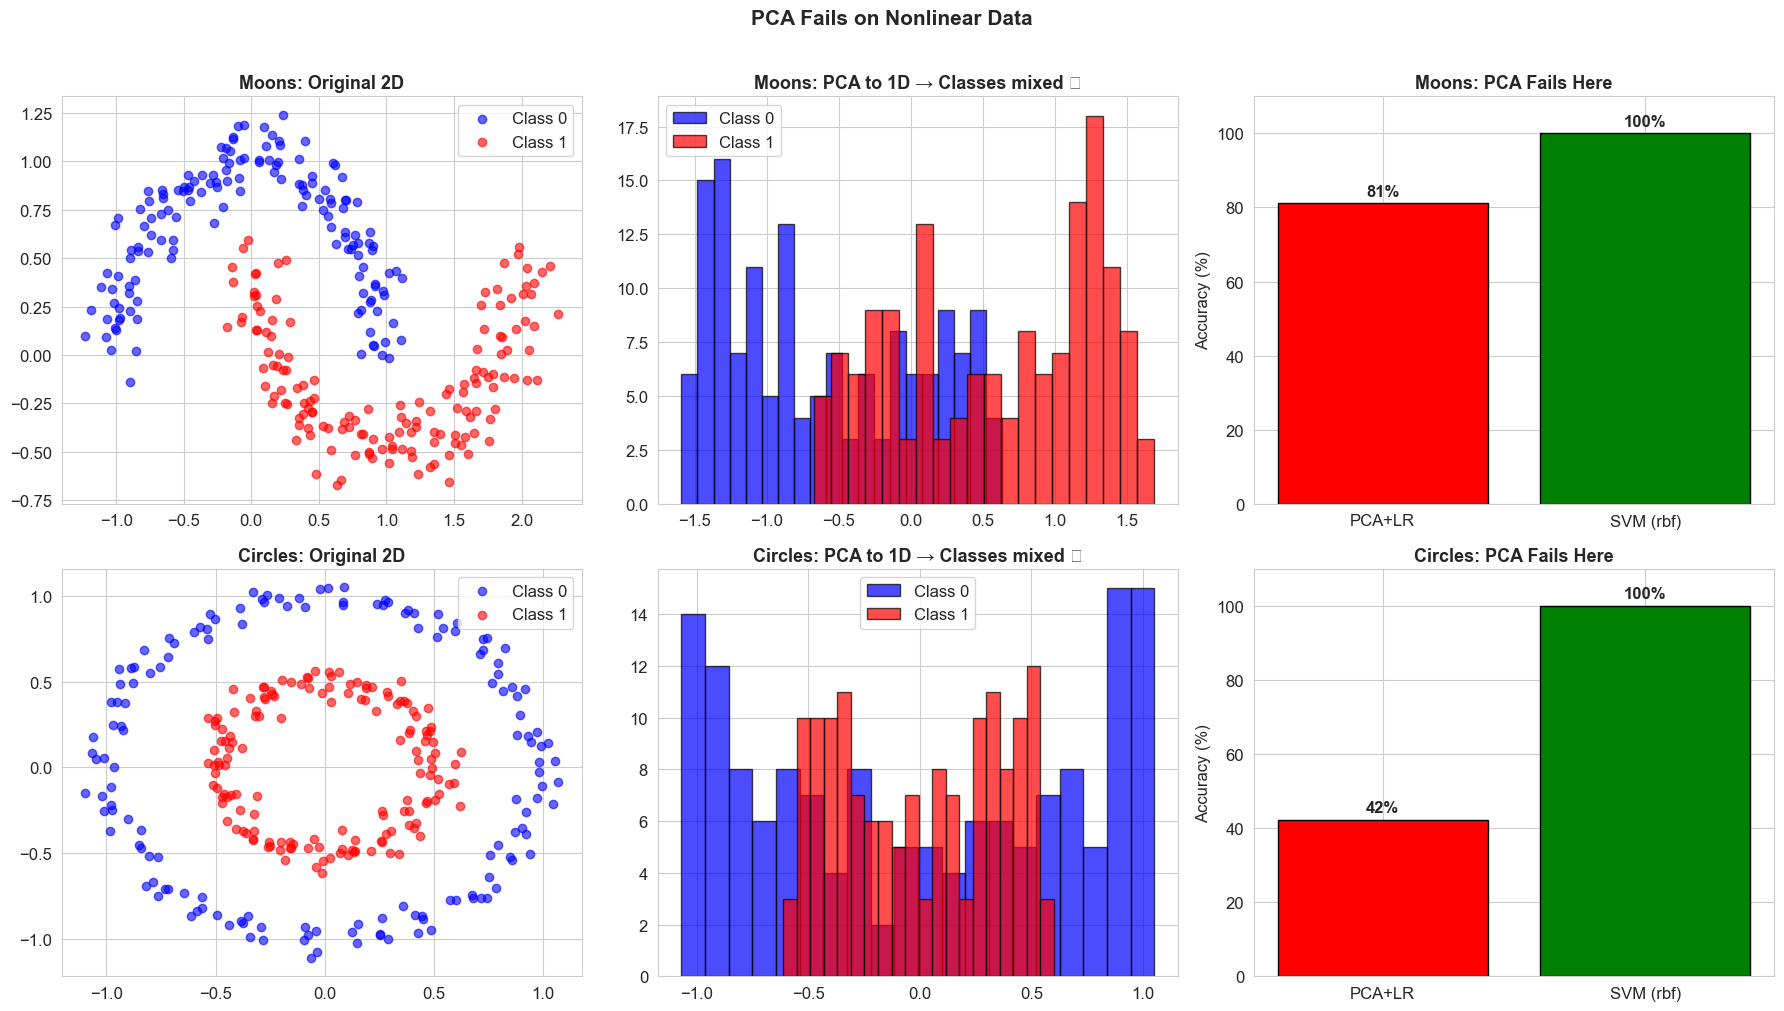

PCA assumes linear structure. For curved/circular data, it projects onto a line
where the classes completely overlap → useless.
Solution: Use Kernel PCA, or a nonlinear model like SVM with RBF kernel.


In [ ]:
# ================================================================
# FAILURE 3: PCA can't handle nonlinear structure
# ================================================================
from sklearn.datasets import make_moons, make_circles

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Make nonlinear datasets
X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)
X_circles, y_circles = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

datasets = [(X_moons, y_moons, 'Moons'), (X_circles, y_circles, 'Circles')]

for col, (X_nl, y_nl, name) in enumerate(datasets):
    # Original
    axes[col, 0].scatter(X_nl[y_nl==0, 0], X_nl[y_nl==0, 1], c='blue', alpha=0.6, label='Class 0')
    axes[col, 0].scatter(X_nl[y_nl==1, 0], X_nl[y_nl==1, 1], c='red', alpha=0.6, label='Class 1')
    axes[col, 0].set_title(f'{name}: Original 2D', fontsize=13, fontweight='bold')
    axes[col, 0].legend()

    # PCA to 1D
    pca_nl = PCA(n_components=1)
    X_pca_nl = pca_nl.fit_transform(X_nl)
    axes[col, 1].hist(X_pca_nl[y_nl==0], bins=20, alpha=0.7, color='blue', label='Class 0', edgecolor='black')
    axes[col, 1].hist(X_pca_nl[y_nl==1], bins=20, alpha=0.7, color='red', label='Class 1', edgecolor='black')
    axes[col, 1].set_title(f'{name}: PCA to 1D → Classes mixed ❌', fontsize=13, fontweight='bold')
    axes[col, 1].legend()

    # PCA accuracy
    X_tr_nl, X_te_nl, y_tr_nl, y_te_nl = train_test_split(X_pca_nl, y_nl, test_size=0.3, random_state=42)
    clf_nl = LogisticRegression()
    clf_nl.fit(X_tr_nl, y_tr_nl)
    acc_pca_nl = accuracy_score(y_te_nl, clf_nl.predict(X_te_nl))

    # SVM on original (can handle nonlinear)
    X_tr_orig, X_te_orig, y_tr_orig, y_te_orig = train_test_split(X_nl, y_nl, test_size=0.3, random_state=42)
    clf_svm = SVC(kernel='rbf')
    clf_svm.fit(X_tr_orig, y_tr_orig)
    acc_svm_nl = accuracy_score(y_te_orig, clf_svm.predict(X_te_orig))

    axes[col, 2].bar(['PCA+LR', 'SVM (rbf)'], [acc_pca_nl*100, acc_svm_nl*100], color=['red', 'green'], edgecolor='black')
    axes[col, 2].set_title(f'{name}: PCA Fails Here', fontsize=13, fontweight='bold')
    axes[col, 2].set_ylabel('Accuracy (%)')
    axes[col, 2].set_ylim(0, 110)
    for j, v in enumerate([acc_pca_nl*100, acc_svm_nl*100]):
        axes[col, 2].text(j, v + 2, f'{v:.0f}%', ha='center', fontweight='bold')

plt.suptitle('PCA Fails on Nonlinear Data', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('PCA assumes linear structure. For curved/circular data, it projects onto a line')
print('where the classes completely overlap → useless.')
print('Solution: Use Kernel PCA, or a nonlinear model like SVM with RBF kernel.')

---
## 15. PCA vs LDA — Side-by-Side Comparison

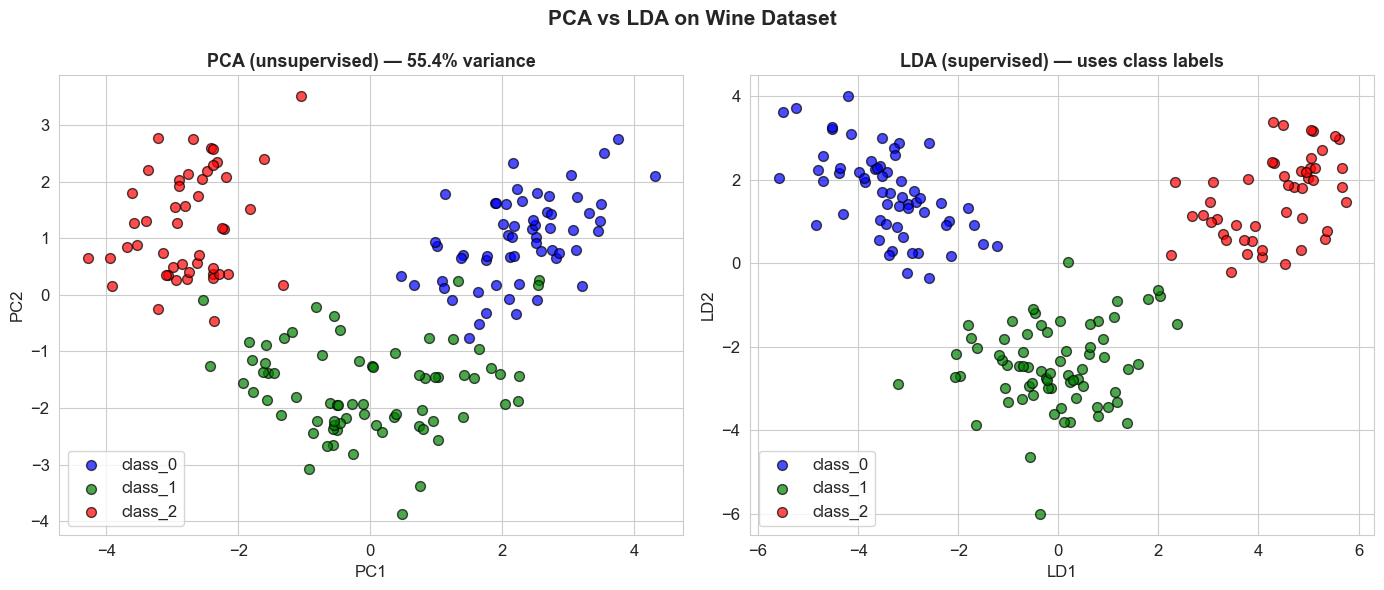


Accuracy with 2 components:
  PCA + LR: 92.6%
  LDA + LR: 100.0%

→ LDA separates classes better because it uses labels.
→ PCA is better when you have no labels or just want to compress/visualize data.


In [ ]:
# ================================================================
# PCA vs LDA on Wine dataset
# ================================================================

wine_data = load_wine()
X_w, y_w = wine_data.data, wine_data.target

scaler_w = StandardScaler()
X_w_scaled = scaler_w.fit_transform(X_w)

# PCA (2 components)
pca_w = PCA(n_components=2)
X_pca_w = pca_w.fit_transform(X_w_scaled)

# LDA (2 components)
lda_w = LinearDiscriminantAnalysis(n_components=2)
X_lda_w = lda_w.fit_transform(X_w_scaled, y_w)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
colors_w = ['blue', 'green', 'red']

for i, (c, name) in enumerate(zip(colors_w, wine_data.target_names)):
    mask = y_w == i
    axes[0].scatter(X_pca_w[mask, 0], X_pca_w[mask, 1], c=c, label=name, alpha=0.7, edgecolors='k', s=50)
    axes[1].scatter(X_lda_w[mask, 0], X_lda_w[mask, 1], c=c, label=name, alpha=0.7, edgecolors='k', s=50)

axes[0].set_title(f'PCA (unsupervised) — {pca_w.explained_variance_ratio_.sum()*100:.1f}% variance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

axes[1].set_title('LDA (supervised) — uses class labels', fontsize=13, fontweight='bold')
axes[1].set_xlabel('LD1')
axes[1].set_ylabel('LD2')
axes[1].legend()

plt.suptitle('PCA vs LDA on Wine Dataset', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Accuracy comparison
X_tr_pw, X_te_pw, y_tr_pw, y_te_pw = train_test_split(X_pca_w, y_w, test_size=0.3, random_state=42, stratify=y_w)
X_tr_lw, X_te_lw, _, _ = train_test_split(X_lda_w, y_w, test_size=0.3, random_state=42, stratify=y_w)

clf_pw = LogisticRegression(max_iter=1000).fit(X_tr_pw, y_tr_pw)
clf_lw = LogisticRegression(max_iter=1000).fit(X_tr_lw, y_tr_pw)

print(f'\nAccuracy with 2 components:')
print(f'  PCA + LR: {accuracy_score(y_te_pw, clf_pw.predict(X_te_pw))*100:.1f}%')
print(f'  LDA + LR: {accuracy_score(y_te_pw, clf_lw.predict(X_te_lw))*100:.1f}%')
print(f'\n→ LDA separates classes better because it uses labels.')
print(f'→ PCA is better when you have no labels or just want to compress/visualize data.')

---
## 16. Summary & Key Takeaways

### What PCA Does
1. Centers the data (subtract mean)
2. Computes the covariance matrix $C$
3. Solves $C\mathbf{w} = \lambda\mathbf{w}$ (eigenvalue problem)
4. Sorts eigenvectors by eigenvalue (largest first)
5. Projects data onto top $k$ eigenvectors

### The Math in One Line
Maximize $\mathbf{w}^T C \mathbf{w}$ subject to $\|\mathbf{w}\| = 1$ → $C\mathbf{w} = \lambda\mathbf{w}$

### When to Use PCA
- Too many features → reduce them
- Want to visualize high-dimensional data in 2D/3D
- Features are correlated/redundant
- No class labels available
- Speed up training (fewer features = faster)
- Reduce overfitting (fewer features = less noise)

### When NOT to Use PCA
- Data is already low-dimensional
- Features have different meanings and you need interpretability
- Variance ≠ importance for your task
- Data has nonlinear structure (use Kernel PCA)
- You have labels and want to classify (use LDA)

### Practical Checklist
1. **Always standardize** before PCA
2. Use **explained variance ratio** to choose number of components
3. 95% variance is a good default threshold
4. Use `PCA(n_components=0.95)` in sklearn for automatic selection
5. Compare model performance **with and without PCA** to verify it helps

### PCA vs LDA Quick Reference

| | PCA | LDA |
|---|---|---|
| Type | Unsupervised | Supervised |
| Maximizes | Variance | Class separation |
| Matrix | $C$ (covariance) | $S_W^{-1} S_B$ |
| Max components | $\min(n, d)$ | $C - 1$ |
| Use when | No labels, visualization, compression | Classification |